# CogniNPC — Test 2: Spojnosc profilu psychologicznego

Weryfikacja, czy odwzorowanie wektora OCEAN na dyrektywy behawioralne
(podrozdzial 5.2.6) wywoluje mierzalne i zgodne z zamierzeniem roznice
w generowanych wypowiedziach.

**Czesc A** — porownanie trzech trybow obslugi wektora osobowosci
(C0 pominiecie / C1 wartosci surowe / C2 dyrektywy).

**Czesc B** — manipulacja natezeniem pojedynczej cechy przy pozostalych
utrzymanych na wartosci srodkowej.

**Zmienne zalezne:** cechy powierzchniowe tekstu odpowiadajace wprost
tresci dyrektyw — dlugosc wypowiedzi, struktura zdaniowa, wskazniki
wahania, zroznicowanie leksykalne, wskazniki nastawienia.

Protokol i metody analizy sa spojne z Testem 1: surowe dane do JSONL,
mediana jako miara tendencji centralnej, testy nieparametryczne,
raportowanie wielkosci efektu.

In [ ]:
import json
import platform
import re
import statistics
import subprocess
import time
import uuid
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

OUT = Path("results_test2")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)

API_BASE = "http://localhost:8000/api"
API_URL = f"{API_BASE}/chat"

# ══════════════════════════════════════════════════════════════════════
# KONFIGURACJA WYMAGAJACA WERYFIKACJI WZGLEDEM schemas.py
# Komorka kontrolna w sekcji 2 sprawdzi poprawnosc tych ustawien
# PRZED uruchomieniem pelnego przebiegu.
# ══════════════════════════════════════════════════════════════════════

PARAM_OCEAN_MODE = "ocean_mode"          # nazwa pola w ChatRequest
PARAM_OCEAN_OVERRIDE = "ocean_override"  # nazwa pola w ChatRequest

# Wartosci parametru trybu wg tabeli 5.4
MODES = {"C0": "none", "C1": "raw", "C2": "full"}

# UWAGA: system uzywa pisowni "extroversion", nie "extraversion".
OCEAN_KEYS = ["openness", "conscientiousness", "extroversion",
              "agreeableness", "neuroticism"]

OCEAN_PL = {
    "openness": "Otwartość",
    "conscientiousness": "Sumienność",
    "extroversion": "Ekstrawersja",
    "agreeableness": "Ugodowość",
    "neuroticism": "Neurotyczność",
}

# Postac o profilu rzeczywistym — czesc A
NPC_REAL = "thorin_01"
# Postac neutralna (pusta lista manieryzmow) — czesc B
NPC_NEUTRAL = "neutral_01"

# ══════════════════════════════════════════════════════════════════════
# PARAMETRY PROTOKOLU
# ══════════════════════════════════════════════════════════════════════

# Limit generowanych tokenow PODNIESIONY wzgledem Testu 1.
#
# UZASADNIENIE: dyrektywa wysokiej ekstrawersji nakazuje odpowiedzi dluzsze.
# Przy limicie 128 tokenow czesc wypowiedzi w warunku wysokim ulegalaby
# obcieciu, co kompresowaloby mierzony efekt i zanizalo roznice miedzy
# pasmami. Limit podniesiono, a odsetek odpowiedzi obcietych kontrolowany
# jest jawnie w sekcji analizy.
NUM_PREDICT = 320

RAG_K = 0            # pamiec wylaczona — patrz podrozdzial 6.4.2
SKIP_MEMORY_WRITE = True

REPS_PER_PROMPT = 6  # powtorzen kazdego zapytania w kazdym warunku
COOLDOWN_S = 0.25
TIMEOUT_S = 300.0
MAX_RETRIES = 2

BACKEND_ERROR_PREFIX = "System error:"

# Poziomy natezenia cechy odpowiadajace trzem pasmom mapowania (tabela 5.3)
TRAIT_LEVELS = [20, 50, 90]
NEUTRAL_LEVEL = 50

# ══════════════════════════════════════════════════════════════════════
# ZESTAW ZAPYTAN
# ══════════════════════════════════════════════════════════════════════
# Zapytania dobrano tak, by byly neutralne wzgledem osobowosci: zadne
# z nich nie sugeruje okreslonego rejestru wypowiedzi ani nie odwoluje sie
# do tla fabularnego konkretnej postaci. Kazde pozostawia jednoczesnie
# swobode co do dlugosci i stylu odpowiedzi, dzieki czemu profil ma sie
# w czym ujawnic. Zapytania z Testu 1 nie nadaja sie do tego celu, poniewaz
# czesc z nich odwoluje sie wprost do historii i pogladow Thorina.

TEST_PROMPTS = [
    ("powitanie",   "Good day. What can you tell me about this place? Please explain in detail."),
    ("informacja",  "A stranger was asking about you yesterday. Tell me everything you think about it."),
    ("prosba",      "I need your help with something difficult. Could you describe your reasoning?"),
    ("ocena",       "Do you think the roads are safe right now? Give me a comprehensive answer."),
    ("osobiste",    "What do you do when you are not working? I want to know the details."),
]

RUN_ID = uuid.uuid4().hex[:12]
RAW_PATH = OUT / f"raw_t2_{RUN_ID}.jsonl"
print(f"run_id = {RUN_ID}\nsurowe dane -> {RAW_PATH}")

run_id = 1f9f8488bad5
surowe dane -> results_test2/raw_t2_1f9f8488bad5.jsonl


## 2. Kontrola wstepna

Komorka sprawdza, czy backend przyjmuje parametry sterujace wektorem
osobowosci. Uruchomienie jej PRZED pelnym przebiegiem pozwala wykryc
niezgodnosc nazw pol w kilka sekund zamiast po kilkunastu minutach.

In [30]:
# def _payload(npc_id, prompt, mode=None, override=None, num_predict=NUM_PREDICT):
#     pl = {
#         "npc_id": npc_id,
#         "player_message": prompt,
#         "skip_memory_write": SKIP_MEMORY_WRITE,
#         "num_predict": num_predict,
#         "rag_k": RAG_K,
#     }
#     if mode is not None:
#         pl[PARAM_OCEAN_MODE] = mode
#     if override is not None:
#         pl[PARAM_OCEAN_OVERRIDE] = override
#     return pl


# def preflight():
#     ok = True
#     with httpx.Client(timeout=60.0) as c:
#         # 1. dostepnosc profili
#         for npc in (NPC_REAL, NPC_NEUTRAL):
#             r = c.get(f"{API_BASE}/npcProfiles/{npc}")
#             if r.status_code != 200:
#                 print(f"  BLAD: brak profilu '{npc}' (HTTP {r.status_code})")
#                 ok = False
#             else:
#                 prof = r.json()
#                 quirks = prof.get("quirks") or []
#                 print(f"  profil '{npc}': OK  | manieryzmow: {len(quirks)}")
#                 if npc == NPC_NEUTRAL and quirks:
#                     print("    UWAGA: profil neutralny ma niepusta liste manieryzmow —")
#                     print("           beda one oddzialywac na mierzone wielkosci.")

#         # 2. akceptacja trybu
#         for label, val in MODES.items():
#             r = c.post(API_URL, json=_payload(NPC_REAL, "Hello.", mode=val, num_predict=16))
#             if r.status_code != 200:
#                 print(f"  BLAD: tryb {label}='{val}' odrzucony (HTTP {r.status_code}): {r.text[:200]}")
#                 ok = False
#             else:
#                 print(f"  tryb {label}='{val}': OK")

#         # 3. akceptacja nadpisania profilu
#         ov = {k: NEUTRAL_LEVEL for k in OCEAN_KEYS}
#         ov["extroversion"] = 90
#         r = c.post(API_URL, json=_payload(NPC_NEUTRAL, "Hello.", mode="full",
#                                           override=ov, num_predict=16))
#         if r.status_code != 200:
#             print(f"  BLAD: nadpisanie profilu odrzucone (HTTP {r.status_code}): {r.text[:300]}")
#             print(f"        wyslana struktura: {json.dumps(ov)}")
#             ok = False
#         else:
#             print("  nadpisanie profilu: OK")

#         # 4. kontrola jakosciowa — czy tryby daja rozne wypowiedzi
#         print("\n  Kontrola jakosciowa (ten sam prompt, rozne tryby):")
#         for label, val in MODES.items():
#             r = c.post(API_URL, json=_payload(NPC_REAL,
#                        "I need your help with something difficult.", mode=val))
#             if r.status_code == 200:
#                 txt = r.json().get("response_text", "")
#                 print(f"    [{label}] {txt[:110]}")

#     print("\n" + ("KONTROLA ZAKONCZONA POWODZENIEM" if ok else
#                   "KONTROLA NIEUDANA — popraw konfiguracje przed przebiegiem"))
#     return ok


# PREFLIGHT_OK = preflight()

## 3. Miary powierzchniowe wypowiedzi

Kazda miara odpowiada wprost tresci konkretnej dyrektywy behawioralnej
(tabela 5.3), co zestawiono w tabeli 6.8. Wyrazenia wyszukujace podano
jawnie, aby pomiar byl odtwarzalny.

In [46]:
# --- Wskazniki wahania -------------------------------------------------
# Formy zaczerpniete WPROST z dyrektywy pasma wysokiego neurotycznosci:
#   "...use 'uhm', 'well...', 'I-I don't know'"
# Zliczanie form spoza dyrektywy mierzyloby zjawisko szersze niz jej
# realizacja, dlatego zestaw jest celowo waski.
RE_FILLER = re.compile(r"\b(?:u+h+m*|e+r+m*|h+m+)\b", re.I)     # uhm, uh, erm, hmm
RE_STUTTER = re.compile(r"\b([A-Za-z])-\1", re.I)                # I-I, w-well
RE_ELLIPSIS = re.compile(r"\.\.\.|\u2026")                       # ... lub …

# --- Wskazniki nastawienia --------------------------------------------
# Dyrektywa pasma wysokiego ugodowosci: "incredibly polite, warm,
# empathetic, and patient... strive to help... avoid conflict".
RE_POLITE = re.compile(
    r"\b(?:please|thank(?:s| you)|sorry|apolog\w+|kindly|"
    r"of course|certainly|gladly|happy to|my pleasure|if you(?:'d| would) like)\b", re.I)
RE_HOSTILE = re.compile(r"\b(?:fool|waste|leave|nonsense|idiot|bother|mind|business)\b", re.I)

RE_WORD = re.compile(r"[A-Za-z']+")
RE_SENT = re.compile(r"[.!?]+(?:\s|$)")
RE_ACTION = re.compile(r"\*[^*]+\*")   # opisy dzialan w gwiazdkach


def text_features(text: str) -> dict:
    """Wyznacza cechy powierzchniowe wypowiedzi."""
    t = (text or "").strip()

    # Opisy dzialan w gwiazdkach usuwane sa z analizy leksykalnej,
    # poniewaz stanowia narracje, nie wypowiedz postaci. Ich liczba
    # raportowana jest osobno.
    n_action = len(RE_ACTION.findall(t))
    t_clean = RE_ACTION.sub(" ", t)

    words = RE_WORD.findall(t_clean.lower())
    n_tok = len(words)
    n_types = len(set(words))

    sents = [s for s in RE_SENT.split(t_clean) if s.strip()]
    n_sent = max(len(sents), 1) if t_clean.strip() else 0

    # Zroznicowanie leksykalne.
    # TTR maleje wraz z dlugoscia tekstu, a dlugosc jest w tym badaniu
    # zmienna zalezna — surowy TTR mieszalby zatem dwa efekty. Obok niego
    # raportowany jest wskaznik Guirauda (types / sqrt(tokens)), znacznie
    # mniej wrazliwy na dlugosc.
    ttr = n_types / n_tok if n_tok else np.nan
    guiraud = n_types / np.sqrt(n_tok) if n_tok else np.nan

    return {
        "chars": len(t),
        "n_words": n_tok,
        "n_sentences": n_sent,
        "mean_sent_words": (n_tok / n_sent) if n_sent else np.nan,
        "mean_word_len": (sum(len(w) for w in words) / n_tok) if n_tok else np.nan,
        "ttr": ttr,
        "guiraud": guiraud,
        "n_filler": len(RE_FILLER.findall(t_clean)),
        "n_stutter": len(RE_STUTTER.findall(t_clean)),
        "n_ellipsis": len(RE_ELLIPSIS.findall(t_clean)),
        "n_hesitation": (len(RE_FILLER.findall(t_clean))
                         + len(RE_STUTTER.findall(t_clean))
                         + len(RE_ELLIPSIS.findall(t_clean))),
        "n_polite": len(RE_POLITE.findall(t_clean)),
        "n_question": t_clean.count("?"),
        "n_exclam": t_clean.count("!"),
        "n_action_desc": n_action,
        "n_hostile": len(RE_HOSTILE.findall(t_clean)),
    }


# Metryki wchodzace do analizy oraz ich polskie nazwy
METRICS = {
    "output_tokens":   "Długość [tokeny]",
    "n_words":         "Długość [słowa]",
    "n_sentences":     "Liczba zdań",
    "mean_sent_words": "Średnia długość zdania",
    "guiraud":         "Zróżnicowanie leksykalne (Guiraud)",
    "mean_word_len":   "Średnia długość słowa",
    "n_hesitation":    "Wskaźniki wahania",
    "n_polite":        "Wskaźniki uprzejmości",
    "n_question":      "Znaki zapytania",
    "n_hostile":       "Wskaźniki wrogości",
}

# Pary cecha–metryka przewidziane przez tresc dyrektyw (tabela 6.8).
# Sluza do wyroznienia na mapie efektow oraz do korekty na wielokrotne
# porownania w wariancie konfirmacyjnym.
PREDICTED = {
    "extroversion":      ["output_tokens", "n_words"],
    "neuroticism":       ["n_hesitation"],
    "conscientiousness": ["mean_sent_words"],
    "openness":          ["guiraud", "mean_word_len"],
    "agreeableness":     ["n_polite", "n_hostile"],
}

# Szybki test poprawnosci wyrazen
_probe = "I-I don't know... uhm, please, would you? *shrugs*"
print(json.dumps({k: v for k, v in text_features(_probe).items()
                  if k in ("n_filler", "n_stutter", "n_ellipsis",
                           "n_hesitation", "n_polite", "n_action_desc")},
                 indent=2))

{
  "n_filler": 1,
  "n_stutter": 1,
  "n_ellipsis": 1,
  "n_hesitation": 3,
  "n_polite": 1,
  "n_action_desc": 1
}


## 4. Telemetria srodowiska

In [32]:
def nvidia_query(field: str):
    try:
        out = subprocess.check_output(
            ["nvidia-smi", f"--query-gpu={field}", "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL, timeout=5)
        return out.decode().strip().splitlines()[0].strip()
    except Exception:
        return None


def env_fingerprint():
    def sh(cmd):
        try:
            return subprocess.check_output(cmd, stderr=subprocess.DEVNULL,
                                           timeout=10).decode().strip()
        except Exception:
            return None
    return {
        "git_commit": sh(["git", "rev-parse", "--short", "HEAD"]),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "gpu_name": nvidia_query("name"),
        "driver": nvidia_query("driver_version"),
    }


ENV = env_fingerprint()
print(json.dumps(ENV, indent=2, ensure_ascii=False))

{
  "git_commit": "73a26e0",
  "python": "3.13.9",
  "platform": "Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35",
  "gpu_name": "NVIDIA GeForce RTX 5070 Ti",
  "driver": "610.74"
}


## 5. Pojedyncze wywolanie

In [33]:
NS_TO_MS = 1e6

def single_request(client, npc_id, prompt, prompt_class,
                   mode=None, override=None) -> dict:
    payload = _payload(npc_id, prompt, mode=mode, override=override)
    last_err = None
    for attempt in range(MAX_RETRIES + 1):
        t0 = time.perf_counter()
        try:
            r = client.post(API_URL, json=payload)
            wall_ms = (time.perf_counter() - t0) * 1000
            r.raise_for_status()
            body = r.json()
            m = body.get("metrics", {}) or {}
            txt = body.get("response_text", "") or ""

            rec = {
                "ok": True,
                "attempt": attempt,
                "wall_ms": round(wall_ms, 2),
                "prompt_class": prompt_class,
                "output_tokens": m.get("eval_count", 0),
                "prompt_tokens": m.get("prompt_eval_count", 0),
                "decode_ms": round(m.get("eval_duration", 0) / NS_TO_MS, 2),
                "response_text": txt,
                "backend_fallback": txt.startswith(BACKEND_ERROR_PREFIX),
            }
            # Kontrola obciecia: odpowiedz osiagajaca limit zostala urwana,
            # a jej dlugosc nie odzwierciedla dzialania dyrektywy.
            rec["truncated"] = (rec["output_tokens"] >= NUM_PREDICT)
            rec.update(text_features(txt))
            return rec
        except Exception as exc:
            last_err = f"{type(exc).__name__}: {exc}"
            time.sleep(1.0)
    return {"ok": False, "error": last_err, "prompt_class": prompt_class}

## 6. Plan eksperymentu

Zapytania i warunki sa w pelni skrzyzowane: kazde zapytanie wykonywane
jest ustalona liczbe razy w kazdym warunku. Rozwiazanie to jest
wlasciwsze od rotacji zastosowanej w Tescie 1, poniewaz tresc zapytania
silnie oddzialuje na dlugosc odpowiedzi — pelne skrzyzowanie gwarantuje
identyczny rozklad zapytan we wszystkich warunkach i pozwala traktowac
zapytanie jako czynnik blokujacy w analizie.


In [34]:
def build_conditions():
    conds = []

    # --- Czesc A: tryb obslugi wektora osobowosci ---
    extreme_override = {
        "openness": 90, "conscientiousness": 90, 
        "extroversion": 90, "agreeableness": 90, "neuroticism": 90
    }
    for label, val in MODES.items():
        conds.append({
            "part": "A", "cond_id": f"A_{label}",
            "npc_id": NPC_NEUTRAL, "mode": val,
            "trait": None, "level": None, "override": extreme_override,
        })

    # --- Czesc B: manipulacja pojedyncza cecha ---
    for trait, level in product(OCEAN_KEYS, TRAIT_LEVELS):
        ov = {k: NEUTRAL_LEVEL for k in OCEAN_KEYS}
        ov[trait] = level
        conds.append({
            "part": "B", "cond_id": f"B_{trait}_{level}",
            "npc_id": NPC_NEUTRAL, "mode": MODES["C2"],
            "trait": trait, "level": level, "override": ov,
        })
    return conds


CONDITIONS = build_conditions()
n_req = len(CONDITIONS) * len(TEST_PROMPTS) * REPS_PER_PROMPT
print(f"Warunkow: {len(CONDITIONS)}  (A: {sum(c['part']=='A' for c in CONDITIONS)}, "
      f"B: {sum(c['part']=='B' for c in CONDITIONS)})")
print(f"Zapytan na warunek: {len(TEST_PROMPTS) * REPS_PER_PROMPT}")
print(f"Zadan lacznie: {n_req}")
print(f"Szacowany czas: ~{n_req * 1.1 / 60:.0f} min")

Warunkow: 18  (A: 3, B: 15)
Zapytan na warunek: 30
Zadan lacznie: 540
Szacowany czas: ~10 min


## 7. Przebieg pomiarowy

In [35]:
RUN_MEASUREMENT = True   # ustaw False, aby przejsc od razu do analizy

if RUN_MEASUREMENT:
    if not PREFLIGHT_OK:
        raise RuntimeError("Kontrola wstepna nie powiodla sie — przerwano.")

    t_start = time.perf_counter()
    with RAW_PATH.open("w", encoding="utf-8") as fh, \
         httpx.Client(timeout=TIMEOUT_S) as client:

        # Rozgrzewka: absorbuje ewentualne ladowanie wag do pamieci karty
        for _ in range(3):
            single_request(client, NPC_REAL, "Hello.", "rozgrzewka", mode=MODES["C2"])

        for ci, cond in enumerate(CONDITIONS, 1):
            print(f"[{ci}/{len(CONDITIONS)}] {cond['cond_id']}", flush=True)
            for (pcls, prompt), rep in product(TEST_PROMPTS, range(REPS_PER_PROMPT)):
                rec = single_request(client, cond["npc_id"], prompt, pcls,
                                     mode=cond["mode"], override=cond["override"])
                fh.write(json.dumps({
                    "run_id": RUN_ID,
                    "ts": datetime.now(timezone.utc).isoformat(),
                    "rep": rep,
                    "part": cond["part"], "cond_id": cond["cond_id"],
                    "npc_id": cond["npc_id"], "mode": cond["mode"],
                    "trait": cond["trait"], "level": cond["level"],
                    **rec,
                    **{f"env_{k}": v for k, v in ENV.items()},
                }, ensure_ascii=False) + "\n")
                time.sleep(COOLDOWN_S)
            fh.flush()

    print(f"\nZakonczono w {(time.perf_counter()-t_start)/60:.1f} min -> {RAW_PATH}")


[1/18] A_C0
[2/18] A_C1
[3/18] A_C2
[4/18] B_openness_20
[5/18] B_openness_50
[6/18] B_openness_90
[7/18] B_conscientiousness_20
[8/18] B_conscientiousness_50
[9/18] B_conscientiousness_90
[10/18] B_extroversion_20
[11/18] B_extroversion_50
[12/18] B_extroversion_90
[13/18] B_agreeableness_20
[14/18] B_agreeableness_50
[15/18] B_agreeableness_90
[16/18] B_neuroticism_20
[17/18] B_neuroticism_50
[18/18] B_neuroticism_90

Zakonczono w 10.0 min -> results_test2/raw_t2_1f9f8488bad5.jsonl


## ANALIZA

In [50]:
rows = [json.loads(l) for l in RAW_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
df = pd.DataFrame(rows)
n_total = len(df)
df = df[df["ok"] == True].copy()  # noqa: E712

n_fb = int(df["backend_fallback"].fillna(False).sum())
if n_fb:
    print(f"!!! Odpowiedzi awaryjnych backendu: {n_fb} — odrzucone")
    df = df[~df["backend_fallback"].fillna(False)].copy()

print(f"Rekordow: {n_total} | do analizy: {len(df)}")

# Kontrola obciecia odpowiedzi
trunc = df.groupby("cond_id")["truncated"].mean().sort_values(ascending=False)
n_trunc = int(df["truncated"].sum())
print(f"\nOdpowiedzi obcietych limitem ({NUM_PREDICT} tok.): {n_trunc} "
      f"({n_trunc/max(len(df),1):.1%})")
if n_trunc:
    print("Warunki o najwyzszym odsetku obciec:")
    print((trunc[trunc > 0] * 100).round(1).head(6).to_string())
    print("\nUWAGA: jesli odsetek przekracza kilka procent w ktorymkolwiek")
    print("warunku, dlugosc odpowiedzi w tym warunku jest zanizona przez")
    print("limit, a nie przez dyrektywe. Nalezy podniesc NUM_PREDICT")
    print("i powtorzyc przebieg albo opisac to jako ograniczenie badania.")

# Kontrola rownowagi zapytan
bal = df.groupby(["cond_id", "prompt_class"]).size().unstack(fill_value=0)
# Rozklad zapytan musi byc rownomierny we wszystkich kombinacjach
counts = bal.to_numpy(dtype="int64", copy=False).ravel()
if counts.size and np.all(counts == counts[0]):
    print(f"\nOK: rozklad zapytan rownomierny ({bal.iloc[0, 0]} na kombinacje).")
else:
    print("\nUWAGA: rozklad zapytan nierownomierny:")
    print(bal.to_string())


Rekordow: 540 | do analizy: 540

Odpowiedzi obcietych limitem (320 tok.): 0 (0.0%)

OK: rozklad zapytan rownomierny (6 na kombinacje).


## 8. Narzedzia statystyczne

Spojne z Testem 1: mediana, bootstrap, testy rangowe, wielkosc efektu.
Dodatkowo korekta na wielokrotne porownania, poniewaz badanie obejmuje
kilkadziesiat testow prowadzonych na tym samym zbiorze danych.

In [51]:
def bootstrap_ci_median(x, n_boot=5000):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(42)
    b = np.median(rng.choice(x, size=(n_boot, len(x)), replace=True), axis=1)
    return float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))


def epsilon_squared(h, n, k):
    return (h - k + 1) / (n - k) if n - k > 0 else np.nan


def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)


def interpret_eps(e):
    if not np.isfinite(e):
        return "nieokreslona"
    a = abs(e)
    return "mala" if a < 0.06 else ("umiarkowana" if a < 0.14 else "duza")


def benjamini_hochberg(pvals, alpha=0.05):
    """Korekta na wielokrotne porownania metoda kontroli FDR.

    Przy kilkudziesieciu testach na tym samym zbiorze czesc wynikow
    istotnych powstaje przypadkiem. Kontrola odsetka falszywych odkryc
    jest tu wlasciwsza od korekty Bonferroniego, ktora przy tej liczbie
    testow bylaby nadmiernie zachowawcza.
    """
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = ranked * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out = np.empty(n)
    out[order] = adj
    return out

## 9. Czesc A — porownanie trybow obslugi wektora osobowosci

In [52]:
dA = df[df["part"] == "A"].copy()
dA["tryb"] = dA["mode"].map({v: k for k, v in MODES.items()})
ORDER_A = ["C0", "C1", "C2"]

rowsA = []
for m, label in METRICS.items():
    r = {"metryka": label}
    for t in ORDER_A:
        v = dA[dA["tryb"] == t][m].dropna()
        if v.empty:
            continue
        lo, hi = bootstrap_ci_median(v)
        r[f"{t}_med"] = round(v.median(), 2)  # type: ignore
        r[f"{t}_ci"] = f"[{lo:.1f}, {hi:.1f}]"
        if v.empty:
            continue
        lo, hi = bootstrap_ci_median(v)
        r[f"{t}_med"] = round(v.median(), 2) # type: ignore
        r[f"{t}_ci"] = f"[{lo:.1f}, {hi:.1f}]"
    rowsA.append(r)

summaryA = pd.DataFrame(rowsA)
summaryA.to_csv(OUT / "tables" / "czescA_mediany.csv", index=False)
display(summaryA)

# --- testy ---
testsA = []
for m, label in METRICS.items():
    groups = [dA[dA["tryb"] == t][m].dropna().values for t in ORDER_A]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        continue

    # Sprawdzenie zerowej wariancji we wszystkich grupach łącznie
    all_vals = np.concatenate([np.asarray(g, dtype=float) for g in groups])
    n = len(all_vals)

    if np.all(all_vals == all_vals[0]):
        # Wariancja = 0: brak różnic między grupami, statystyka = 0, p = 1.0
        testsA.append({
            "metryka": label, "porownanie": "C0 / C1 / C2",
            "test": "Kruskal-Wallis", "stat": 0.0,
            "p": 1.0, "efekt": 0.0, "n": n
        })
    else:
        h, pv = stats.kruskal(*groups)
        testsA.append({
            "metryka": label, "porownanie": "C0 / C1 / C2",
            "test": "Kruskal-Wallis", "stat": round(h, 2),
            "p": pv, "efekt": round(epsilon_squared(h, n, len(groups)), 3), "n": n
        })

    # Kluczowe porownanie: czy dyrektywy wnosza cos ponad wartosci surowe (C1 vs C2)
    a = dA[dA["tryb"] == "C1"][m].dropna().values
    b = dA[dA["tryb"] == "C2"][m].dropna().values
    if len(a) >= 3 and len(b) >= 3:
        n_ab = len(a) + len(b)
        combined_ab = np.concatenate([
            np.asarray(a, dtype=float),
            np.asarray(b, dtype=float),
        ])
        if np.all(combined_ab == combined_ab[0]):
            testsA.append({
                "metryka": label, "porownanie": "C1 wobec C2",
                "test": "Mann-Whitney U", "stat": (len(a) * len(b)) / 2.0,
                "p": 1.0, "efekt": 0.0,
                "n": n_ab
            })
        else:
            u, pv2 = stats.mannwhitneyu(a, b, alternative="two-sided")
            testsA.append({
                "metryka": label, "porownanie": "C1 wobec C2",
                "test": "Mann-Whitney U", "stat": round(u, 1),
                "p": pv2, "efekt": round(rank_biserial(u, len(a), len(b)), 3),
                "n": n_ab
            })

testsA = pd.DataFrame(testsA)
if not testsA.empty:
    testsA["p_BH"] = benjamini_hochberg(testsA["p"].values)
    testsA["istotny_BH"] = testsA["p_BH"] < 0.05
    def fmt_p(x):
        if pd.isna(x):
            return np.nan
        x = float(x)
        return f"{x:.2e}" if x < 1e-3 else round(x, 4)
    testsA["p"] = testsA["p"].map(fmt_p)
    testsA["p_BH"] = testsA["p_BH"].map(lambda x: f"{x:.2e}" if pd.notna(x) and float(x) < 1e-3 else (round(float(x), 4) if pd.notna(x) else np.nan))
    testsA.to_csv(OUT / "tables" / "czescA_testy.csv", index=False)
    display(testsA)

,metryka,C0_med,C0_ci,C1_med,C1_ci,C2_med,C2_ci
0,Długość [tokeny],67.00,"[49.5, 74.5]",73.50,"[63.5, 84.0]",112.50,"[103.5, 118.0]"
1,Długość [słowa],50.50,"[39.5, 56.0]",54.50,"[48.0, 62.5]",82.00,"[75.0, 85.5]"
2,Liczba zdań,4.00,"[4.0, 4.0]",4.00,"[3.0, 4.0]",6.00,"[5.0, 6.0]"
3,Średnia długość zdania,12.62,"[10.0, 14.0]",15.12,"[11.4, 15.7]",14.83,"[13.2, 16.0]"
4,Zróżnicowanie leksykalne (Guiraud),6.41,"[6.0, 6.6]",6.42,"[6.3, 6.8]",7.51,"[7.3, 7.6]"
5,Średnia długość słowa,4.36,"[4.3, 4.5]",4.49,"[4.3, 4.6]",4.61,"[4.6, 4.7]"
6,Wskaźniki wahania,0.00,"[0.0, 0.0]",0.00,"[0.0, 0.0]",4.00,"[4.0, 5.0]"
7,Wskaźniki uprzejmości,0.00,"[0.0, 0.0]",0.00,"[0.0, 0.0]",0.00,"[0.0, 0.0]"
8,Znaki zapytania,0.50,"[0.0, 1.0]",0.00,"[0.0, 1.0]",0.00,"[0.0, 0.5]"
9,Wskaźniki wrogości,0.00,"[0.0, 0.0]",0.00,"[0.0, 0.0]",0.00,"[0.0, 0.0]"


,metryka,porownanie,test,stat,p,efekt,n,p_BH,istotny_BH
0,Długość [tokeny],C0 / C1 / C2,Kruskal-Wallis,53.45,2.48e-12,0.591,90,2.48e-11,True
1,Długość [tokeny],C1 wobec C2,Mann-Whitney U,49.50,3.32e-09,0.890,60,1.11e-08,True
2,Długość [słowa],C0 / C1 / C2,Kruskal-Wallis,47.36,5.21e-11,0.521,90,2.60e-10,True
3,Długość [słowa],C1 wobec C2,Mann-Whitney U,68.00,1.68e-08,0.849,60,4.79e-08,True
4,Liczba zdań,C0 / C1 / C2,Kruskal-Wallis,25.28,3.23e-06,0.268,90,7.18e-06,True
5,Liczba zdań,C1 wobec C2,Mann-Whitney U,191.50,9.78e-05,0.574,60,1.96e-04,True
6,Średnia długość zdania,C0 / C1 / C2,Kruskal-Wallis,5.49,0.0642,0.040,90,0.0988,False
7,Średnia długość zdania,C1 wobec C2,Mann-Whitney U,388.50,0.367,0.137,60,0.4587,False
8,Zróżnicowanie leksykalne (Guiraud),C0 / C1 / C2,Kruskal-Wallis,40.50,1.61e-09,0.443,90,6.42e-09,True
9,Zróżnicowanie leksykalne (Guiraud),C1 wobec C2,Mann-Whitney U,94.50,1.53e-07,0.790,60,3.83e-07,True


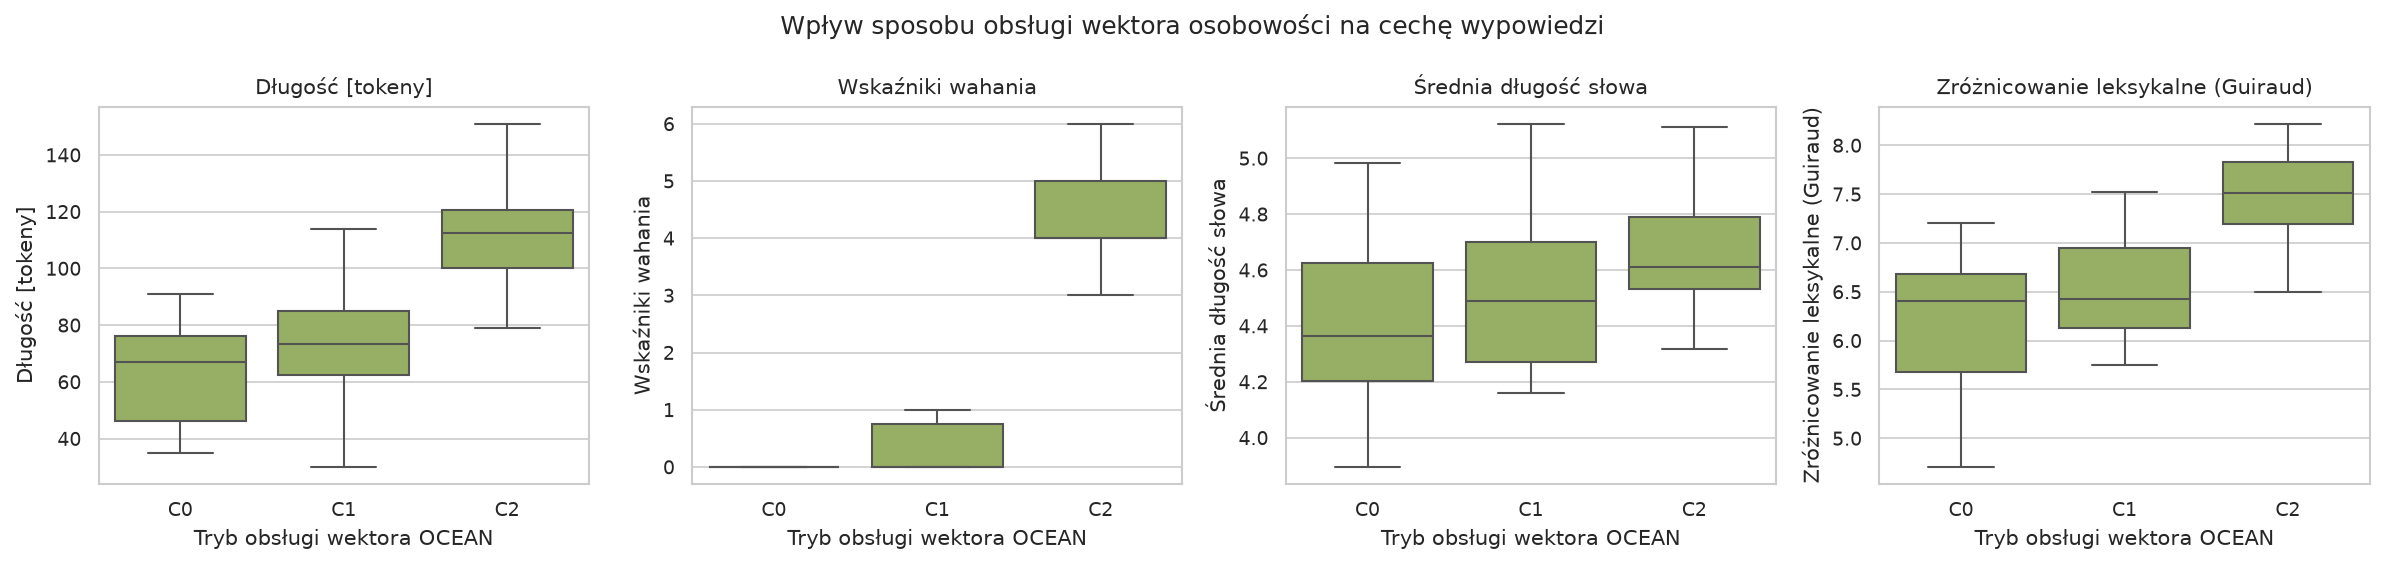

In [57]:
# --- Rys. 6.6: kluczowe metryki wobec trybu ---
key_metrics = ["output_tokens", "n_hesitation", "mean_word_len", "guiraud"]
fig, axes = plt.subplots(1, len(key_metrics), figsize=(4 * len(key_metrics), 3.8))
for ax, m in zip(np.atleast_1d(axes), key_metrics):
    sns.boxplot(data=dA, x="tryb", y=m, order=ORDER_A, showfliers=False,
                ax=ax, color="#9bbb59")
    ax.set(xlabel="Tryb obsługi wektora OCEAN", ylabel=METRICS[m], title=METRICS[m])
fig.suptitle("Wpływ sposobu obsługi wektora osobowości na cechę wypowiedzi")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUT / "figures" / f"rys6_6_tryby.{ext}")
plt.show()

## 10. Czesc B — manipulacja natezeniem pojedynczej cechy

Dla kazdej pary cecha–metryka wyznaczana jest sila efektu oraz kierunek
zaleznosci. Zestawienie w postaci macierzy pozwala ocenic nie tylko
skutecznosc dyrektyw, lecz rowniez ich SWOISTOSC: dyrektywa dobrze
skonstruowana powinna oddzialywac na wielkosc, ktorej dotyczy, a nie
na wszystkie naraz.

In [54]:
dB = df[df["part"] == "B"].copy()

rowsB = []
for trait, m in product(OCEAN_KEYS, METRICS.keys()):
    sub = dB[dB["trait"] == trait]
    groups = [sub[sub["level"] == lv][m].dropna().values for lv in TRAIT_LEVELS]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        continue
    h, pv = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eps = epsilon_squared(h, n, len(groups))
    rho, p_rho = stats.spearmanr(sub["level"], sub[m])
    rowsB.append({
        "cecha": OCEAN_PL[trait], "trait": trait,
        "metryka": METRICS[m], "metric": m,
        "H": round(h, 2), "p_KW": pv, "eps2": round(eps, 3),
        "rho": round(rho, 3), "p_rho": p_rho, # type: ignore
        "przewidziana": m in PREDICTED.get(trait, []),
        "n": n,
    })

resB = pd.DataFrame(rowsB)
resB["p_KW_BH"] = benjamini_hochberg(resB["p_KW"].values)
resB["p_rho_BH"] = benjamini_hochberg(resB["p_rho"].values)
resB["istotny_BH"] = resB["p_KW_BH"] < 0.05
resB.to_csv(OUT / "tables" / "czescB_pelna_macierz.csv", index=False)

# Zestawienie dla par przewidzianych przez tresc dyrektyw
pred = resB[resB["przewidziana"]].copy()
pred_show = pred[["cecha", "metryka", "H", "eps2", "rho", "n"]].copy()
pred_show["p (BH)"] = pred["p_KW_BH"].map(lambda x: f"{x:.2e}" if x < 1e-3 else round(x, 4)) # type: ignore
pred_show["interpretacja"] = pred["eps2"].map(interpret_eps)
pred_show.to_csv(OUT / "tables" / "czescB_pary_przewidziane.csv", index=False)
print("Pary cecha–metryka przewidziane przez tresc dyrektyw:")
display(pred_show)

Pary cecha–metryka przewidziane przez tresc dyrektyw:


,cecha,metryka,H,eps2,rho,n,p (BH),interpretacja
4,Otwartosc,Zróżnicowanie leksykalne (Guiraud),12.31,0.119,0.360,90,0.0076,umiarkowana
5,Otwartosc,Średnia długość słowa,6.31,0.050,0.255,90,0.1119,mala
13,Sumiennosc,Średnia długość zdania,4.05,0.024,0.211,90,0.2604,mala
20,Ekstrawersja,Długość [tokeny],35.17,0.381,0.629,90,3.84e-07,duza
21,Ekstrawersja,Długość [słowa],37.08,0.403,0.645,90,2.22e-07,duza
37,Ugodowosc,Wskaźniki uprzejmości,1.11,-0.010,0.058,90,0.6928,mala
39,Ugodowosc,Wskaźniki wrogości,2.67,0.008,-0.040,90,0.4388,mala
46,Neurotycznosc,Wskaźniki wahania,74.68,0.835,0.802,90,3.03e-15,duza


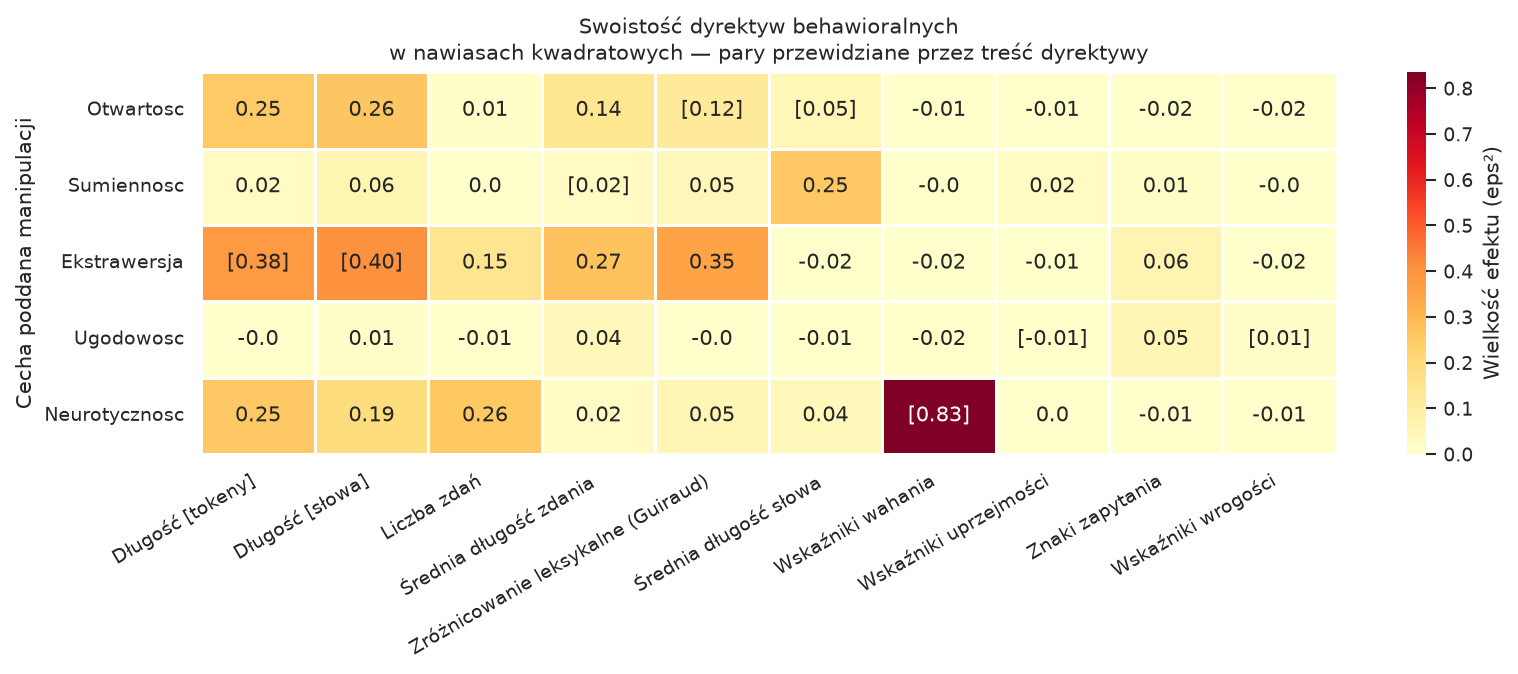

In [56]:
# --- Rys. 6.7: macierz swoistosci dyrektyw ---
mat = resB.pivot(index="cecha", columns="metryka", values="eps2")
mat = mat.reindex(index=[OCEAN_PL[t] for t in OCEAN_KEYS],
                  columns=[METRICS[m] for m in METRICS])

# Oznaczenie par przewidzianych ramka
annot = mat.round(2).astype(str)
for _, r in resB.iterrows():
    if r["przewidziana"]:
        annot.loc[r["cecha"], r["metryka"]] = f"[{r['eps2']:.2f}]"

fig, ax = plt.subplots(figsize=(11, 4.6))
sns.heatmap(mat, annot=annot, fmt="", cmap="YlOrRd", vmin=0, vmax=max(0.3, mat.max().max()),
            linewidths=0.5, cbar_kws={"label": "Wielkość efektu (eps\u00b2)"}, ax=ax)
ax.set(xlabel="", ylabel="Cecha poddana manipulacji",
       title="Swoistość dyrektyw behawioralnych\n"
             "w nawiasach kwadratowych — pary przewidziane przez treść dyrektywy")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUT / "figures" / f"rys6_7_swoistosc.{ext}")
plt.show()


/tmp/ipykernel_25538/2004206187.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([str(v) for v in TRAIT_LEVELS])
/tmp/ipykernel_25538/2004206187.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([str(v) for v in TRAIT_LEVELS])
/tmp/ipykernel_25538/2004206187.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([str(v) for v in TRAIT_LEVELS])
/tmp/ipykernel_25538/2004206187.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([str(v) 

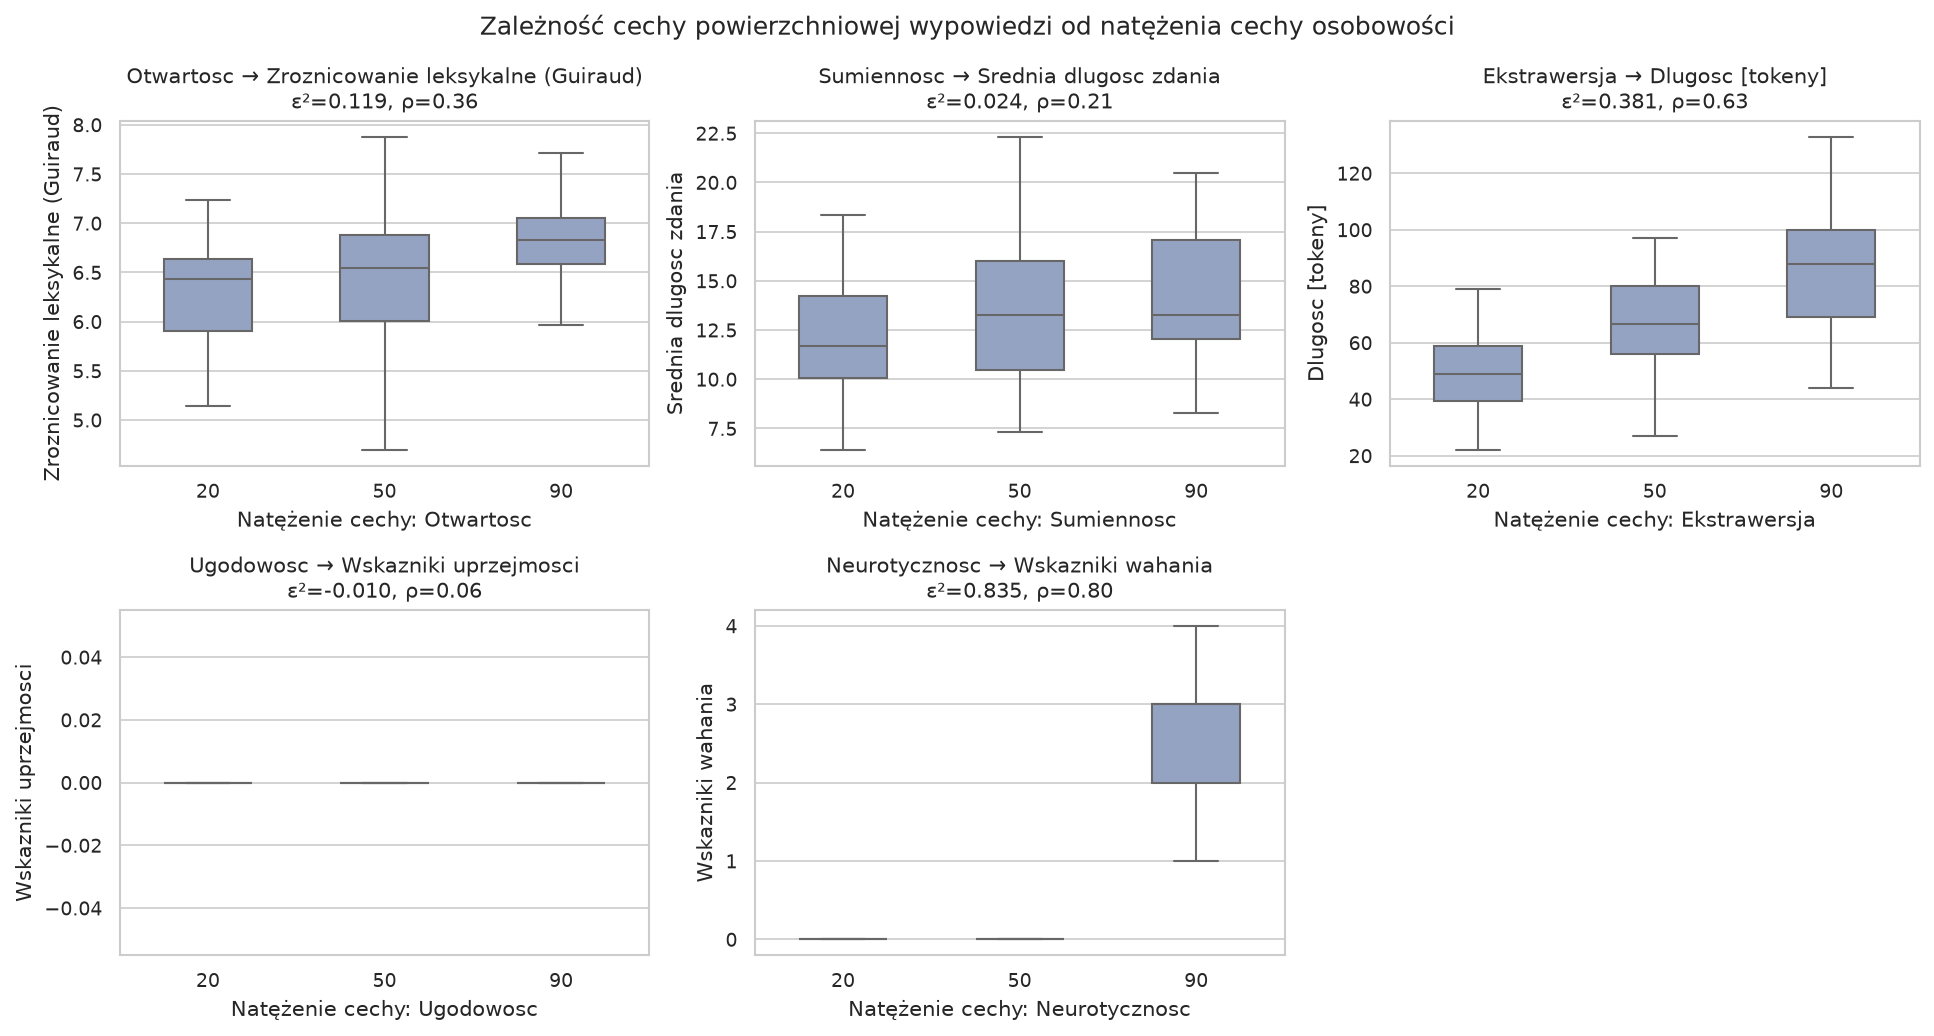

In [44]:
# --- Rys. 6.8: przebieg metryki przewidzianej wobec natężenia cechy ---

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Obsługa polskich znaków
plt.rcParams["font.family"] = "DejaVu Sans"

pairs = [(t, PREDICTED[t][0]) for t in OCEAN_KEYS if PREDICTED.get(t)]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, (trait, m) in zip(axes.ravel(), pairs):
    sub = dB[dB["trait"] == trait].copy()
    sub["level"] = pd.Categorical(
        sub["level"],
        categories=TRAIT_LEVELS,
        ordered=True
    )

    sns.boxplot(
        data=sub,
        x="level",
        y=m,
        order=TRAIT_LEVELS,
        showfliers=False,
        ax=ax,
        color="#8da0cb",
        width=0.5,
    )

    ax.set_xticklabels([str(v) for v in TRAIT_LEVELS])

    ax.set_xlabel(f"Natężenie cechy: {OCEAN_PL[trait]}")
    ax.set_ylabel(METRICS[m])

    row = resB[
        (resB["trait"] == trait) &
        (resB["metric"] == m)
    ]

    sub_t = (
        f"ε²={row['eps2'].iloc[0]:.3f}, "
        f"ρ={row['rho'].iloc[0]:.2f}"
        if len(row)
        else ""
    )

    ax.set_title(
        f"{OCEAN_PL[trait]} → {METRICS[m]}\n{sub_t}"
    )

# Wyłączenie niewykorzystanych pól
for ax in axes.ravel()[len(pairs):]:
    ax.axis("off")

fig.suptitle(
    "Zależność cechy powierzchniowej wypowiedzi "
    "od natężenia cechy osobowości"
)

fig.tight_layout()

for ext in ("png", "pdf"):
    fig.savefig(
        OUT / "figures" / f"rys6_8_przebiegi.{ext}",
        bbox_inches="tight"
    )

plt.show()

## 11. Podsumowanie

In [43]:
print("=" * 70)
print("PODSUMOWANIE TESTU 2")
print("=" * 70)
print(f"Postac (czesc A): {NPC_REAL} | postac (czesc B): {NPC_NEUTRAL}")
print(f"Warunkow: {len(CONDITIONS)} | obserwacji: {len(df)}")
print(f"Zapytan: {len(TEST_PROMPTS)} x {REPS_PER_PROMPT} powtorzen na warunek")
print(f"Limit tokenow: {NUM_PREDICT} | odpowiedzi obcietych: {n_trunc}")
print("-" * 70)

print("CZESC A — czy dyrektywy wnosza cos ponad wartosci surowe (C1 wobec C2):")
if isinstance(testsA, pd.DataFrame) and not testsA.empty:
    sel = testsA[testsA["porownanie"] == "C1 wobec C2"]
    if not sel.empty:
        for _, r in sel.iterrows():
            mark = "istotne" if bool(r["istotny_BH"]) else "nieistotne"
            print(f"   {r['metryka']:36s} r={r['efekt']:+.3f}  {mark}")

print("-" * 70)
print("CZESC B — pary przewidziane przez tresc dyrektyw:")
for _, r in pred.iterrows():
    mark = "potwierdzona" if r["p_KW_BH"] < 0.05 else "NIEPOTWIERDZONA"
    print(f"   {r['cecha']:14s} -> {r['metryka']:34s} "
          f"eps2={r['eps2']:.3f} rho={r['rho']:+.2f}  {mark}")

print("-" * 70)
n_sig_pred = int((pred["p_KW_BH"] < 0.05).sum())
n_sig_other = int(((resB["p_KW_BH"] < 0.05) & (~resB["przewidziana"])).sum())
print(f"Par przewidzianych potwierdzonych: {n_sig_pred}/{len(pred)}")
print(f"Par nieprzewidzianych istotnych:   {n_sig_other}/{(~resB['przewidziana']).sum()}")
print("\nWysoki udzial par nieprzewidzianych oznaczalby, ze dyrektywy")
print("oddzialuja na wypowiedz szeroko, a nie w sposob swoisty — co nalezy")
print("omowic przy interpretacji wynikow.")
print("=" * 70)
print(f"\nTabele  -> {OUT/'tables'}")
print(f"Wykresy -> {OUT/'figures'}")

PODSUMOWANIE TESTU 2
Postac (czesc A): thorin_01 | postac (czesc B): neutral_01
Warunkow: 18 | obserwacji: 540
Zapytan: 5 x 6 powtorzen na warunek
Limit tokenow: 320 | odpowiedzi obcietych: 0
----------------------------------------------------------------------
CZESC A — czy dyrektywy wnosza cos ponad wartosci surowe (C1 wobec C2):
   Dlugosc [tokeny]                     r=+0.890  istotne
   Dlugosc [slowa]                      r=+0.849  istotne
   Liczba zdan                          r=+0.574  istotne
   Srednia dlugosc zdania               r=+0.137  nieistotne
   Zroznicowanie leksykalne (Guiraud)   r=+0.790  istotne
   Srednia dlugosc slowa                r=+0.311  nieistotne
   Wskazniki wahania                    r=+0.982  istotne
   Wskazniki uprzejmosci                r=+0.068  nieistotne
   Znaki zapytania                      r=-0.109  nieistotne
   Wskazniki wrogosci                   r=-0.020  nieistotne
----------------------------------------------------------------------